In [14]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
import os
from tqdm.autonotebook import tqdm
sys.path.append(os.path.join("/Users/jiandachen/Projects/NNCAM_packages/nncam_training/dataloader"))
from dataloader_utils import get_index_from_colnames

In [9]:
data_dir = "test_data"

In [13]:
target_col_names = "dqvls_nn_in"
col_names = np.loadtxt(data_dir + "/col_names.txt", dtype=str)
indices = get_index_from_colnames(col_names, target_col_names)
print(indices)

(593, 623)


In [17]:
data_dir = "test_data"
all_files = glob.glob(data_dir + "/*.npy")

all_data = []
for file in tqdm(all_files):
    data = np.load(file)[indices[0]:indices[1]]
    all_data.append(data)

100%|██████████| 582/582 [00:39<00:00, 14.63it/s]


In [19]:
all_data = np.concatenate([data[None,] for data in all_data], axis=0)
print(all_data.shape)

(582, 30, 96, 144)


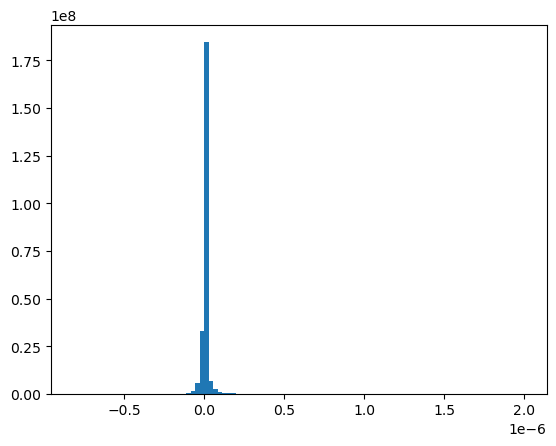

In [22]:
plt.hist(all_data.flatten(), bins=100)
plt.show()

In [23]:
print(all_data.mean())
print(all_data.std())

5.265831442981117e-09
5.0653298050373313e-08


In [24]:
means = np.load(data_dir + "/data_means.npz")
stds = np.load(data_dir + "/data_stds.npz")

In [26]:
print(means["dqvls_nn_in"])
print(stds["dqvls_nn_in"])

4.846803319856428e-09
4.895941322496681e-08


In [27]:
norm_data = (all_data - means["dqvls_nn_in"]) / stds["dqvls_nn_in"]

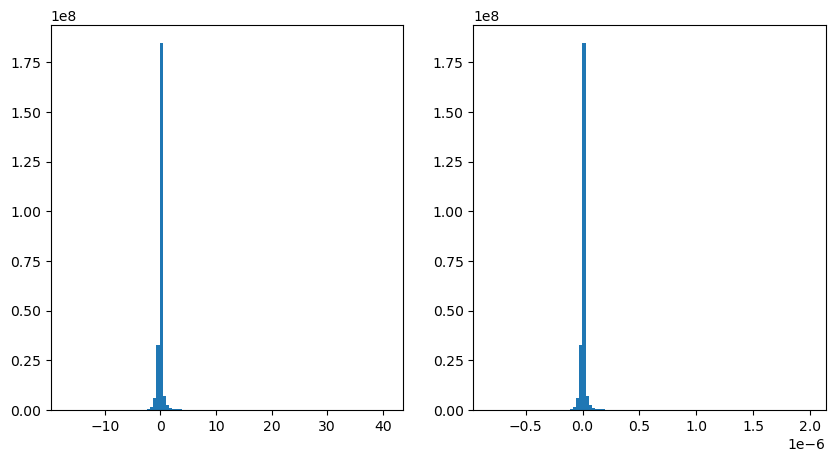

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(norm_data.flatten(), bins=100)
ax[1].hist(all_data.flatten(), bins=100)
plt.show()

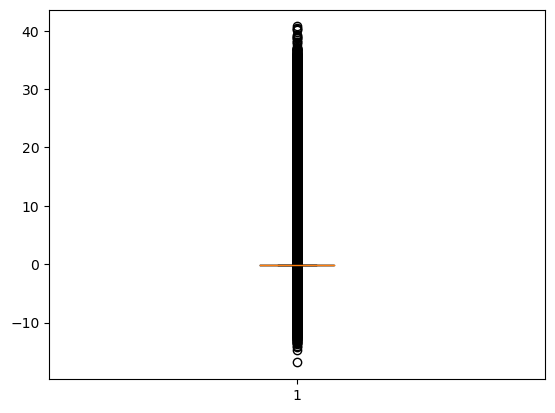

In [29]:
plt.boxplot(norm_data.flatten())
plt.show()

In [31]:
print(norm_data.mean())
print(norm_data.std())

0.008558683520149567
1.0345977354267526


In [37]:
dqvls_raw = np.load("../dataloader/dqvls_raw.npy")
dqvls_norm = np.load("../dataloader/dqvls_norm.npy")
print(dqvls_raw.shape)
print(dqvls_norm.shape)

(49, 30, 96, 144)
(49, 13824, 30)


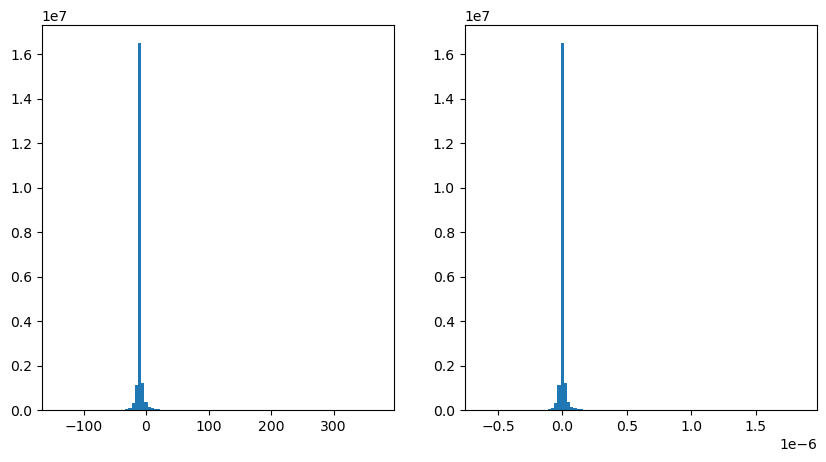

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(dqvls_norm.flatten(), bins=100)
ax[1].hist(dqvls_raw.flatten(), bins=100)
plt.show()

In [39]:
print(dqvls_raw.mean())
print(dqvls_raw.std())
print(dqvls_norm.mean())
print(dqvls_norm.std())

5.269212925733425e-09
5.0639248493440884e-08
-9.014230084444113
10.447968516894761


In [41]:
dqvls_norm2 = (dqvls_raw - means["dqvls_nn_in"]) / stds["dqvls_nn_in"]
print(dqvls_norm2.mean())
print(dqvls_norm2.std())

0.00862775058058863
1.0343107720828963
